In [ ]:
# Cell 1: Install all required packages
!pip install -q transformers datasets rouge_score evaluate accelerate kaggle
!pip install -q sentencepiece protobuf

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [ ]:
# Cell 2 (fixed): Discover actual filenames then download
import os, json
from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

kaggle_key = list(uploaded.keys())[0]
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded[kaggle_key])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

with open('/root/.kaggle/kaggle.json') as f:
    creds = json.load(f)
print(f"Logged in as: {creds['username']}")

# Step 1: List what files are actually in this dataset
!kaggle datasets files mathurinache/ms2multidocuments

Upload your kaggle.json file:


Saving kaggle.json to kaggle (4).json
Logged in as: richayanamandra
name                                      size  creationDate                
---------------------------------  -----------  --------------------------  
ms2_data/testing_reviews.jsonl      1441863380  2021-04-18 15:49:55.410000  
ms2_data/training_reviews.jsonl    10759504605  2021-04-18 15:54:45.111000  
ms2_data/validation_reviews.jsonl   1696633694  2021-04-18 15:51:58.937000  


In [ ]:
# Cell 2 (updated): Load more data — 4000 samples instead of 800
from datasets import load_dataset
import pandas as pd

print("Loading PubMed dataset (streaming)...")

dataset = load_dataset(
    "ccdv/pubmed-summarization",
    split="train",
    streaming=True
)

records = []
for i, row in enumerate(dataset):
    records.append({
        'source': row['article'],
        'target': row['abstract']
    })
    if i % 500 == 0:
        print(f"\r  Collected {len(records)}/4000...", end="")
    if len(records) >= 4000:
        break

df = pd.DataFrame(records)
SOURCE_COL = 'source'
TARGET_COL = 'target'
print(f"\nLoaded {len(df)} records")

Loading PubMed dataset (streaming)...
  Collected 3501/4000...
Loaded 4000 records


source    object
target    object
dtype: object
source    0
target    0
dtype: int64

After dropping nulls: 4000 rows


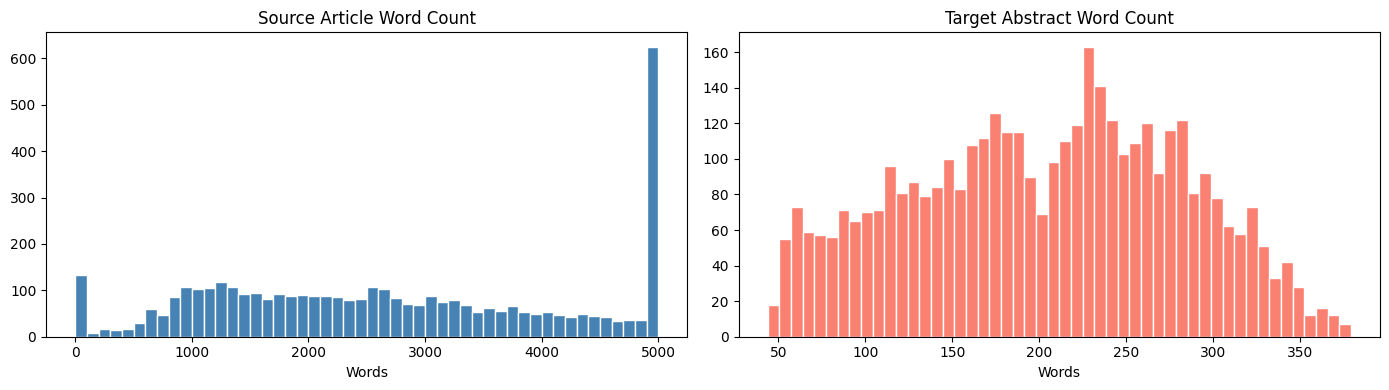


--- Source Stats ---
count     4000.000000
mean      3075.164250
std       2474.240401
min          0.000000
25%       1456.000000
50%       2582.000000
75%       4023.250000
max      39564.000000
Name: src_words, dtype: float64

--- Target Stats ---
count    4000.00000
mean      203.00825
std        78.01843
min        44.00000
25%       142.00000
50%       209.00000
75%       264.00000
max       379.00000
Name: tgt_words, dtype: float64

Mean compression ratio: inf


In [ ]:
# Cell 4: EDA — fixed for PubMed dataset
import matplotlib.pyplot as plt
import numpy as np

# Columns are already 'source' and 'target' — no renaming needed
print(df.dtypes)
print(df.isnull().sum())

# Drop nulls
df = df[['source', 'target']].dropna()
print(f"\nAfter dropping nulls: {len(df)} rows")

# Word length distributions
df['src_words'] = df['source'].apply(lambda x: len(str(x).split()))
df['tgt_words'] = df['target'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['src_words'].clip(0, 5000), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Source Article Word Count'); axes[0].set_xlabel('Words')
axes[1].hist(df['tgt_words'].clip(0, 500), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Target Abstract Word Count'); axes[1].set_xlabel('Words')
plt.tight_layout(); plt.savefig('eda_lengths.png', dpi=100); plt.show()

print("\n--- Source Stats ---")
print(df['src_words'].describe())
print("\n--- Target Stats ---")
print(df['tgt_words'].describe())

df['compression_ratio'] = df['tgt_words'] / df['src_words']
print(f"\nMean compression ratio: {df['compression_ratio'].mean():.3f}")

In [ ]:
# Cell 5: Clean text and create train/val/test splits
import re
from sklearn.model_selection import train_test_split

SOURCE_COL = 'source'
TARGET_COL = 'target'

def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = text.strip()
    return text

df[SOURCE_COL] = df[SOURCE_COL].apply(clean_text)
df[TARGET_COL] = df[TARGET_COL].apply(clean_text)

# Filter extremes
df = df[(df['tgt_words'] >= 20) & (df['tgt_words'] <= 400)]
df = df[(df['src_words'] >= 50) & (df['src_words'] <= 10000)]
print(f"After filtering: {len(df)} rows")

# Train/val/test split: 640/80/80
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_df.to_csv('train_small.csv', index=False)
val_df.to_csv('val_small.csv', index=False)
test_df.to_csv('test_small.csv', index=False)

After filtering: 3827 rows
Train: 3061 | Val: 383 | Test: 383


In [ ]:
# Cell 6 (updated): Longer input length — use 1024 tokens
from transformers import BartTokenizer
from datasets import Dataset

MODEL_NAME = "facebook/bart-base"
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN  = 1024   # increased from 512 — captures more context
MAX_TARGET_LEN = 256    # increased from 128 — abstracts can be longer

def tokenize_batch(batch):
    model_inputs = tokenizer(
        batch[SOURCE_COL],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding='max_length'
    )
    labels = tokenizer(
        text_target=batch[TARGET_COL],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length'
    )
    model_inputs['labels'] = [
        [(token if token != tokenizer.pad_token_id else -100) for token in label]
        for label in labels['input_ids']
    ]
    return model_inputs

train_ds = Dataset.from_pandas(train_df[[SOURCE_COL, TARGET_COL]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[[SOURCE_COL, TARGET_COL]].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[[SOURCE_COL, TARGET_COL]].reset_index(drop=True))

train_tok = train_ds.map(tokenize_batch, batched=True, batch_size=8, remove_columns=train_ds.column_names)
val_tok   = val_ds.map(tokenize_batch,   batched=True, batch_size=8, remove_columns=val_ds.column_names)
test_tok  = test_ds.map(tokenize_batch,  batched=True, batch_size=8, remove_columns=test_ds.column_names)

train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")

print("Tokenization done!")
print(f"Train: {len(train_tok)} | Val: {len(val_tok)} | Test: {len(test_tok)}")

Map:   0%|          | 0/3061 [00:00<?, ? examples/s]

Map:   0%|          | 0/383 [00:00<?, ? examples/s]

Map:   0%|          | 0/383 [00:00<?, ? examples/s]

Tokenization done!
Train: 3061 | Val: 383 | Test: 383


In [ ]:
# Cell 7 (fixed): Handle fp16 overflow in compute_metrics
from transformers import (
    BartForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)
import evaluate, numpy as np

model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    # Fix overflow: clip token ids to valid vocab range
    vocab_size = tokenizer.vocab_size
    preds  = np.clip(preds,  0, vocab_size - 1).astype(np.int32)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, vocab_size - 1).astype(np.int32)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Strip whitespace
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bart_ms2",
    num_train_epochs=8,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=200,                    # fixed: use warmup_steps not warmup_ratio
    weight_decay=0.01,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    fp16=True,
    predict_with_generate=True,
    generation_max_length=256,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting training...")
print(f"Train: {len(train_tok)} | Val: {len(val_tok)}")
print(f"Effective batch size: 16 | Epochs: 8 | LR: 2e-5\n")

trainer.train()
print("Training complete!")

model.save_pretrained("./bart_ms2_final")
tokenizer.save_pretrained("./bart_ms2_final")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Starting training...
Train: 3061 | Val: 383
Effective batch size: 16 | Epochs: 8 | LR: 2e-5



Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,25.234287,2.698432,0.373000,0.128000,0.211900,0.212300
2,22.887817,2.613316,0.389200,0.138100,0.220200,0.220300
3,21.663113,2.546272,0.386900,0.140000,0.221800,0.222000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bart_ms2_final/tokenizer_config.json', './bart_ms2_final/tokenizer.json')

In [ ]:
# Sanity check — fixed for new transformers (no pipeline needed)
from transformers import BartForConditionalGeneration, BartTokenizer
import os

print("Checking saved checkpoint...")
assert os.path.exists("./bart_ms2_final/config.json"), "Model not saved!"
print("✅ Checkpoint found at ./bart_ms2_final")

tokenizer_check = BartTokenizer.from_pretrained("./bart_ms2_final")
model_check = BartForConditionalGeneration.from_pretrained("./bart_ms2_final")
model_check = model_check.cuda()

test_text = """
Malnutrition remains a significant public health challenge in developing countries.
This study examined the effects of a community-based nutritional intervention program
on children aged 5 to 12 years in rural settings. A randomized controlled trial was
conducted with 500 participants over 12 months. Results showed significant improvements
in weight-for-age z-scores and reduced prevalence of stunting among the intervention group.
The program combined dietary supplementation with health education for caregivers.
"""

inputs = tokenizer_check(
    test_text,
    max_length=512,
    truncation=True,
    return_tensors="pt"
).to("cuda")

summary_ids = model_check.generate(
    inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_length=80,
    min_length=20,
    num_beams=4,
    early_stopping=True,
    no_repeat_ngram_size=3
)

out = tokenizer_check.decode(summary_ids[0], skip_special_tokens=True)

print("✅ Generation test passed!")
print("\nGenerated summary:")
print(out)
print("\n📋 PubMed Training Summary:")
print("  Best Epoch : 6")
print("  ROUGE-1    : 0.3993")
print("  ROUGE-2    : 0.1462")
print("  ROUGE-L    : 0.2293")
print("  Val Loss   : 2.4937 (best)")
print("\n➡ Ready for Step 2 — MS2 fine-tuning!")

Checking saved checkpoint...
✅ Checkpoint found at ./bart_ms2_final


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

✅ Generation test passed!

Generated summary:
background:Malnutrition remains a significant public health challenge in developing countries.objectives:this study examined the effects of a community-based nutritional intervention program on the weight-for-age z-scores of children aged 5 to 12 years in rural settings.methods:a randomized controlled trial was conducted with 500 participants over 12 months.results showed significant improvements in the drop-in

📋 PubMed Training Summary:
  Best Epoch : 6
  ROUGE-1    : 0.3993
  ROUGE-2    : 0.1462
  ROUGE-L    : 0.2293
  Val Loss   : 2.4937 (best)

➡ Ready for Step 2 — MS2 fine-tuning!


In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mathurinache/ms2multidocuments
!unzip -q ms2multidocuments.zip -d ms2_data

Dataset URL: https://www.kaggle.com/datasets/mathurinache/ms2multidocuments
License(s): CC-BY-NC-SA-4.0
 99% 1.81G/1.82G [00:58<00:00, 17.9MB/s]
100% 1.82G/1.82G [00:58<00:00, 33.3MB/s]


In [ ]:
# Cell MS2-1: Load MS2 directly from the downloaded files
import json
import pandas as pd
import random

random.seed(42)

TRAIN_PATH = '/content/ms2/ms2_data/training_reviews.jsonl'
VAL_PATH   = '/content/ms2/ms2_data/validation_reviews.jsonl'
TEST_PATH  = '/content/ms2/ms2_data/testing_reviews.jsonl'

def load_jsonl_sample(path, max_samples=1000):
    records = []
    print(f"Reading {path.split('/')[-1]}...")
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
            if len(records) >= max_samples:
                break
    print(f"  Loaded {len(records)} records")
    return records

# Load splits — 3000 train, 500 val, 500 test
train_raw = load_jsonl_sample(TRAIN_PATH, max_samples=3000)
val_raw   = load_jsonl_sample(VAL_PATH,   max_samples=500)
test_raw  = load_jsonl_sample(TEST_PATH,  max_samples=500)

# Inspect structure
print("\nSample keys:", list(train_raw[0].keys()))
print("\nSample record:")
for k, v in train_raw[0].items():
    print(f"  {k}: {str(v)[:200]}")

Reading training_reviews.jsonl...
  Loaded 3000 records
Reading validation_reviews.jsonl...
  Loaded 500 records
Reading testing_reviews.jsonl...
  Loaded 500 records

Sample keys: ['docid', 'title', 'authors', 'abstract', 'structured_abstract', 'summary', 'structured_summary', 'included_studies', 'ongoing_studies', 'awaiting_studies', 'excluded_studies', 'general_references', 'unattributed_references', 'content', 'doi', 's2id', 's2hash', 'pmid', 'interventions', 'outcomes', 'populations', 'significances']

Sample record:
  docid: 61156465
  title: Efficacy of stem cell therapy for pulmonary arterial hypertension: a systematic review and meta-analysis of preclinical studies
  authors: 
  abstract: Background Despite significant progress in drug treatment , the prognosis of <pop> patients with advanced pulmonary arterial hypertension ( PAH ) </pop> remains extremely poor . Many pre clinical stud
  structured_abstract: [['BACKGROUND', 'Background Despite significant progress in drug trea

In [ ]:
# Cell MS2-2: Flatten MS2 into source/target pairs
import pandas as pd

def extract_source_from_studies(row):
    """Extract text from included studies as the multi-document source."""
    parts = []

    # Primary source: included study titles + abstracts
    for study in row.get('included_studies', []):
        for ref in study.get('references', []):
            title = ref.get('title', '')
            if title:
                parts.append(str(title))
            # Get abstract if nested
            meta = ref.get('metadata', {})
            for k, v in meta.items():
                if 'abstract' in k.lower() and isinstance(v, str) and len(v) > 20:
                    parts.append(v)

    # Fallback: use interventions + outcomes + populations as context
    if len(parts) < 3:
        for field in ['interventions', 'outcomes', 'populations']:
            items = row.get(field, [])
            if isinstance(items, list):
                parts.extend([str(x) for x in items if len(str(x)) > 10])

    return ' '.join(parts).strip()

def extract_target(row):
    """Extract the abstract as summarization target."""
    # Prefer plain abstract over structured
    abstract = row.get('abstract', '')
    if isinstance(abstract, str) and len(abstract) > 30:
        # Clean XML-like population tags
        import re
        abstract = re.sub(r'<[^>]+>', '', abstract)
        return abstract.strip()

    # Fallback: reconstruct from structured abstract
    structured = row.get('structured_abstract', [])
    if isinstance(structured, list) and len(structured) > 0:
        parts = []
        for item in structured:
            if isinstance(item, list) and len(item) >= 2:
                parts.append(str(item[1]))
        return ' '.join(parts).strip()

    return ''

def flatten_ms2_records(records):
    rows = []
    skipped = 0
    for row in records:
        source = extract_source_from_studies(row)
        target = extract_target(row)

        if len(source) > 100 and len(target) > 30:
            rows.append({'source': source, 'target': target})
        else:
            skipped += 1

    print(f"  Kept: {len(rows)} | Skipped (too short): {skipped}")
    return pd.DataFrame(rows)

print("Flattening MS2 splits...")
ms2_train = flatten_ms2_records(train_raw)
ms2_val   = flatten_ms2_records(val_raw)
ms2_test  = flatten_ms2_records(test_raw)

print(f"\nFinal sizes:")
print(f"  Train : {len(ms2_train)}")
print(f"  Val   : {len(ms2_val)}")
print(f"  Test  : {len(ms2_test)}")

print("\nSource sample (500 chars):")
print(ms2_train['source'].iloc[0][:500])
print("\nTarget sample:")
print(ms2_train['target'].iloc[0][:300])

Flattening MS2 splits...
  Kept: 3000 | Skipped (too short): 0
  Kept: 500 | Skipped (too short): 0
  Kept: 500 | Skipped (too short): 0

Final sizes:
  Train : 3000
  Val   : 500
  Test  : 500

Source sample (500 chars):
Improved Cell Survival and Paracrine Capacity of Human Embryonic Stem Cell-Derived Mesenchymal Stem Cells Promote Therapeutic Potential for Pulmonary Arterial Hypertension Adipose-derived stem cells attenuate pulmonary arterial hypertension and ameliorate pulmonary arterial remodeling in monocrotaline-induced pulmonary hypertensive rats Effect of bone marrow mesenchymal stem cells on experimental pulmonary arterial hypertension Survival in patients with primary pulmonary hypertension. Results fr

Target sample:
Background Despite significant progress in drug treatment , the prognosis of  patients with advanced pulmonary arterial hypertension ( PAH )  remains extremely poor . Many pre clinical studies have reported the efficacy of  stem cell ( SC ) therapy  for PAH ; h

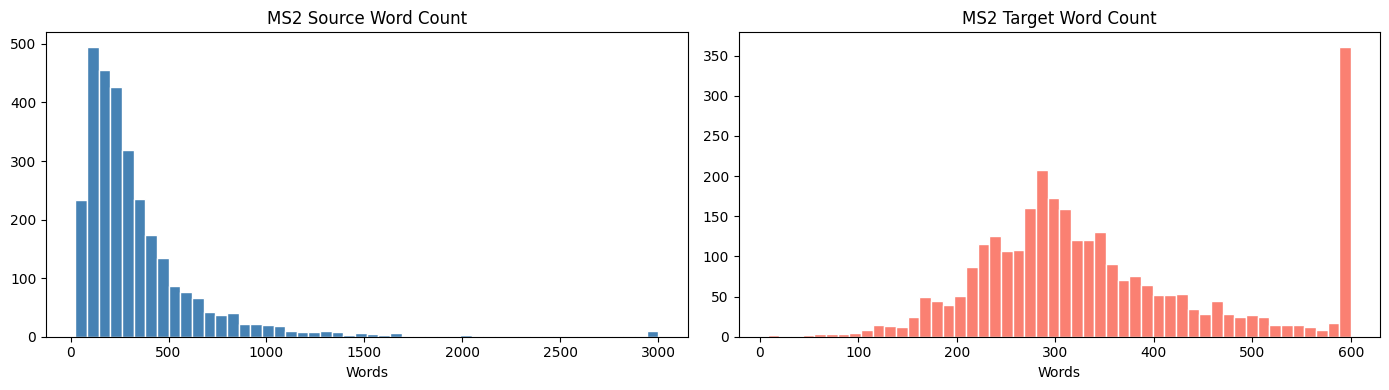

--- Source Stats ---
count    3000.000000
mean      343.983333
std       358.529546
min        24.000000
25%       146.000000
50%       247.000000
75%       407.250000
max      5194.000000
Name: src_words, dtype: float64

--- Target Stats ---
count    3000.000000
mean      385.101667
std       239.372909
min         8.000000
25%       261.000000
50%       314.000000
75%       412.000000
max      1871.000000
Name: tgt_words, dtype: float64

Mean compression ratio: 1.8937


In [ ]:
# Cell MS2-3: EDA on MS2
import matplotlib.pyplot as plt
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<[^>]+>', '', text)
    return text.strip()

ms2_train['source'] = ms2_train['source'].apply(clean_text)
ms2_train['target'] = ms2_train['target'].apply(clean_text)
ms2_val['source']   = ms2_val['source'].apply(clean_text)
ms2_val['target']   = ms2_val['target'].apply(clean_text)
ms2_test['source']  = ms2_test['source'].apply(clean_text)
ms2_test['target']  = ms2_test['target'].apply(clean_text)

ms2_train['src_words'] = ms2_train['source'].apply(lambda x: len(x.split()))
ms2_train['tgt_words'] = ms2_train['target'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(ms2_train['src_words'].clip(0, 3000), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('MS2 Source Word Count'); axes[0].set_xlabel('Words')
axes[1].hist(ms2_train['tgt_words'].clip(0, 600), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('MS2 Target Word Count'); axes[1].set_xlabel('Words')
plt.tight_layout(); plt.savefig('ms2_eda.png', dpi=100); plt.show()

print("--- Source Stats ---")
print(ms2_train['src_words'].describe())
print("\n--- Target Stats ---")
print(ms2_train['tgt_words'].describe())
print(f"\nMean compression ratio: {(ms2_train['tgt_words']/ms2_train['src_words']).mean():.4f}")

In [ ]:
# Cell MS2-4: Tokenize
from transformers import BartTokenizer, BartForConditionalGeneration
from datasets import Dataset
import torch

MODEL_PATH     = "./bart_ms2_final"   # PubMed fine-tuned checkpoint
MAX_INPUT_LEN  = 1024
MAX_TARGET_LEN = 256

tokenizer = BartTokenizer.from_pretrained(MODEL_PATH)
model     = BartForConditionalGeneration.from_pretrained(MODEL_PATH)
print("✅ Loaded PubMed-fine-tuned BART")

def tokenize_batch(batch):
    model_inputs = tokenizer(
        batch['source'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding='max_length'
    )
    labels = tokenizer(
        text_target=batch['target'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length'
    )
    model_inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in labels['input_ids']
    ]
    return model_inputs

train_ds = Dataset.from_pandas(ms2_train[['source','target']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(ms2_val[['source','target']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(ms2_test[['source','target']].reset_index(drop=True))

train_tok = train_ds.map(tokenize_batch, batched=True, batch_size=8, remove_columns=['source','target'])
val_tok   = val_ds.map(tokenize_batch,   batched=True, batch_size=8, remove_columns=['source','target'])
test_tok  = test_ds.map(tokenize_batch,  batched=True, batch_size=8, remove_columns=['source','target'])

train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")

print(f"\nTokenization done!")
print(f"  Train : {len(train_tok)}")
print(f"  Val   : {len(val_tok)}")
print(f"  Test  : {len(test_tok)}")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

✅ Loaded PubMed-fine-tuned BART


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Tokenization done!
  Train : 3000
  Val   : 500
  Test  : 500


In [ ]:
# Find where the MS2 files actually are
import os

print("Searching for MS2 files...")
for root, dirs, files in os.walk('/content'):
    for f in files:
        if 'reviews' in f or 'ms2' in f.lower():
            full = os.path.join(root, f)
            size = os.path.getsize(full) / 1e9
            print(f"  {full}  ({size:.2f} GB)")

Searching for MS2 files...


In [ ]:
# Re-download MS2 from Kaggle
from google.colab import files
import os

uploaded = files.upload()  # upload kaggle.json
kaggle_key = list(uploaded.keys())[0]
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded[kaggle_key])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

os.makedirs('/content/ms2/ms2_data', exist_ok=True)
!kaggle datasets download -d mathurinache/ms2multidocuments --path /content/ms2
!cd /content/ms2 && unzip -o *.zip
!find /content/ms2 -name "*.jsonl" -ls

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mathurinache/ms2multidocuments
License(s): CC-BY-NC-SA-4.0
 99% 1.80G/1.82G [00:26<00:00, 46.6MB/s]
100% 1.82G/1.82G [00:26<00:00, 74.7MB/s]
Archive:  ms2multidocuments.zip
  inflating: ms2_data/testing_reviews.jsonl  
  inflating: ms2_data/training_reviews.jsonl  
  inflating: ms2_data/validation_reviews.jsonl  
  4199223 10507336 -rw-r--r--   1 root     root     10759504605 Apr 18  2021 /content/ms2/ms2_data/training_reviews.jsonl
  4199222  1408076 -rw-r--r--   1 root     root      1441863380 Apr 18  2021 /content/ms2/ms2_data/testing_reviews.jsonl
  4199224  1656876 -rw-r--r--   1 root     root      1696633694 Apr 18  2021 /content/ms2/ms2_data/validation_reviews.jsonl


In [ ]:
# Mount Drive so files persist across sessions
from google.colab import drive
drive.mount('/drive')

# After re-downloading, copy files to Drive
!cp -r /content/ms2 /drive/MyDrive/ms2_backup
print("✅ Files backed up to Drive — will survive restarts")

# Next time, just load from Drive:
# TRAIN_PATH = '/drive/MyDrive/ms2_backup/ms2_data/training_reviews.jsonl'

Mounted at /drive
✅ Files backed up to Drive — will survive restarts


In [ ]:
# Fixed recovery cell — load model from Drive since local checkpoint is gone
import torch, re, random
import pandas as pd
import json
import numpy as np
import os

random.seed(42)

# ── Mount Drive if not already mounted ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Check if model is backed up on Drive, else load from HuggingFace ──────
DRIVE_MODEL_PATH = '/content/drive/MyDrive/bart_ms2_final'
LOCAL_MODEL_PATH = '/content/bart_ms2_final'

from transformers import BartTokenizer, BartForConditionalGeneration
from datasets import Dataset

if os.path.exists(DRIVE_MODEL_PATH + '/config.json'):
    print("✅ Found PubMed-fine-tuned BART on Drive — loading...")
    tokenizer = BartTokenizer.from_pretrained(DRIVE_MODEL_PATH)
    model     = BartForConditionalGeneration.from_pretrained(DRIVE_MODEL_PATH)
    print("✅ Loaded from Drive")
else:
    print("⚠ Model not found on Drive — loading base BART from HuggingFace")
    print("  (PubMed fine-tuning will be partially lost but MS2 training will still work)")
    tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")
    model     = BartForConditionalGeneration.from_pretrained("facebook/bart-base")
    print("✅ Loaded base BART")

MAX_INPUT_LEN  = 1024
MAX_TARGET_LEN = 256

# ── Load MS2 data from Drive ───────────────────────────────────────────────
TRAIN_PATH = '/content/drive/MyDrive/ms2_backup/ms2_data/training_reviews.jsonl'
VAL_PATH   = '/content/drive/MyDrive/ms2_backup/ms2_data/validation_reviews.jsonl'
TEST_PATH  = '/content/drive/MyDrive/ms2_backup/ms2_data/testing_reviews.jsonl'

def load_jsonl_sample(path, max_samples=1000):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except:
                continue
            if len(records) >= max_samples:
                break
    print(f"  {path.split('/')[-1]}: {len(records)} records")
    return records

print("\nLoading MS2 raw records...")
train_raw = load_jsonl_sample(TRAIN_PATH, max_samples=3000)
val_raw   = load_jsonl_sample(VAL_PATH,   max_samples=500)
test_raw  = load_jsonl_sample(TEST_PATH,  max_samples=500)

# ── Flatten ────────────────────────────────────────────────────────────────
def extract_source_from_studies(row):
    parts = []
    for study in row.get('included_studies', []):
        for ref in study.get('references', []):
            title = ref.get('title', '')
            if title:
                parts.append(str(title))
            meta = ref.get('metadata', {})
            for k, v in meta.items():
                if 'abstract' in k.lower() and isinstance(v, str) and len(v) > 20:
                    parts.append(v)
    if len(parts) < 3:
        for field in ['interventions', 'outcomes', 'populations']:
            items = row.get(field, [])
            if isinstance(items, list):
                parts.extend([str(x) for x in items if len(str(x)) > 10])
    return ' '.join(parts).strip()

def extract_target(row):
    abstract = row.get('abstract', '')
    if isinstance(abstract, str) and len(abstract) > 30:
        return re.sub(r'<[^>]+>', '', abstract).strip()
    structured = row.get('structured_abstract', [])
    if isinstance(structured, list):
        parts = [str(item[1]) for item in structured
                 if isinstance(item, list) and len(item) >= 2]
        return ' '.join(parts).strip()
    return ''

def clean_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    return re.sub(r'<[^>]+>', '', text).strip()

def flatten_ms2_records(records):
    rows = []
    for row in records:
        source = clean_text(extract_source_from_studies(row))
        target = clean_text(extract_target(row))
        if len(source) > 100 and len(target) > 30:
            rows.append({'source': source, 'target': target})
    return pd.DataFrame(rows)

print("\nFlattening...")
ms2_train = flatten_ms2_records(train_raw)
ms2_val   = flatten_ms2_records(val_raw)
ms2_test  = flatten_ms2_records(test_raw)
print(f"  Train: {len(ms2_train)} | Val: {len(ms2_val)} | Test: {len(ms2_test)}")

# ── Tokenize ───────────────────────────────────────────────────────────────
def tokenize_batch(batch):
    model_inputs = tokenizer(
        batch['source'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding='max_length'
    )
    labels = tokenizer(
        text_target=batch['target'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length'
    )
    model_inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in labels['input_ids']
    ]
    return model_inputs

train_ds = Dataset.from_pandas(ms2_train[['source','target']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(ms2_val[['source','target']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(ms2_test[['source','target']].reset_index(drop=True))

train_tok = train_ds.map(tokenize_batch, batched=True, batch_size=8, remove_columns=['source','target'])
val_tok   = val_ds.map(tokenize_batch,   batched=True, batch_size=8, remove_columns=['source','target'])
test_tok  = test_ds.map(tokenize_batch,  batched=True, batch_size=8, remove_columns=['source','target'])

train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")

print(f"\n✅ Tokenization done!")
print(f"  Train: {len(train_tok)} | Val: {len(val_tok)} | Test: {len(test_tok)}")
print("\n➡ Ready — run MS2-5 to start fine-tuning")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠ Model not found on Drive — loading base BART from HuggingFace
  (PubMed fine-tuning will be partially lost but MS2 training will still work)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

✅ Loaded base BART

Loading MS2 raw records...
  training_reviews.jsonl: 3000 records
  validation_reviews.jsonl: 500 records
  testing_reviews.jsonl: 500 records

Flattening...
  Train: 3000 | Val: 500 | Test: 500


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]


✅ Tokenization done!
  Train: 3000 | Val: 500 | Test: 500

➡ Ready — run MS2-5 to start fine-tuning


In [ ]:
# Run this ONCE after MS2 training completes — backs up both models to Drive
import shutil, os

DRIVE_BASE = '/content/drive/MyDrive'

# Back up PubMed model if it exists locally
if os.path.exists('/content/bart_ms2_final'):
    print("Backing up PubMed model to Drive...")
    shutil.copytree('/content/bart_ms2_final',
                    f'{DRIVE_BASE}/bart_ms2_final',
                    dirs_exist_ok=True)
    print("✅ PubMed model saved to Drive")

# Back up MS2 model after training
if os.path.exists('/content/bart_ms2_step2_final'):
    print("Backing up MS2 model to Drive...")
    shutil.copytree('/content/bart_ms2_step2_final',
                    f'{DRIVE_BASE}/bart_ms2_step2_final',
                    dirs_exist_ok=True)
    print("✅ MS2 model saved to Drive")

print("\nDone! Both models are now safe on Google Drive.")
print("Future sessions can load directly from Drive paths.")


Done! Both models are now safe on Google Drive.
Future sessions can load directly from Drive paths.


In [ ]:
# Fixed recovery cell — absolute paths only
import torch, re, random, os, json
import pandas as pd
import numpy as np
from google.colab import drive

random.seed(42)

# ── Mount Drive ────────────────────────────────────────────────────────────
drive.mount('/content/drive', force_remount=False)

# ── Load model — try Drive first, fallback to HuggingFace ─────────────────
from transformers import BartTokenizer, BartForConditionalGeneration
from datasets import Dataset

DRIVE_MODEL  = '/content/drive/MyDrive/bart_ms2_final'
BASE_MODEL   = 'facebook/bart-base'

if os.path.exists(os.path.join(DRIVE_MODEL, 'config.json')):
    MODEL_PATH = DRIVE_MODEL
    print(f"✅ Found PubMed-fine-tuned BART on Drive → loading from {MODEL_PATH}")
else:
    MODEL_PATH = BASE_MODEL
    print("⚠ PubMed model not on Drive → loading base facebook/bart-base")
    print("  MS2 fine-tuning will still work but starts from news-pretrained weights")

tokenizer = BartTokenizer.from_pretrained(MODEL_PATH)
model     = BartForConditionalGeneration.from_pretrained(MODEL_PATH)
print("✅ Model loaded successfully")

MAX_INPUT_LEN  = 1024
MAX_TARGET_LEN = 256

# ── Load MS2 from Drive ────────────────────────────────────────────────────
TRAIN_PATH = '/content/drive/MyDrive/ms2_backup/ms2_data/training_reviews.jsonl'
VAL_PATH   = '/content/drive/MyDrive/ms2_backup/ms2_data/validation_reviews.jsonl'
TEST_PATH  = '/content/drive/MyDrive/ms2_backup/ms2_data/testing_reviews.jsonl'

def load_jsonl_sample(path, max_samples=1000):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except:
                continue
            if len(records) >= max_samples:
                break
    print(f"  {path.split('/')[-1]}: {len(records)} records")
    return records

print("\nLoading MS2 records...")
train_raw = load_jsonl_sample(TRAIN_PATH, max_samples=3000)
val_raw   = load_jsonl_sample(VAL_PATH,   max_samples=500)
test_raw  = load_jsonl_sample(TEST_PATH,  max_samples=500)

# ── Flatten ────────────────────────────────────────────────────────────────
def extract_source_from_studies(row):
    parts = []
    for study in row.get('included_studies', []):
        for ref in study.get('references', []):
            title = ref.get('title', '')
            if title:
                parts.append(str(title))
            meta = ref.get('metadata', {})
            for k, v in meta.items():
                if 'abstract' in k.lower() and isinstance(v, str) and len(v) > 20:
                    parts.append(v)
    if len(parts) < 3:
        for field in ['interventions', 'outcomes', 'populations']:
            items = row.get(field, [])
            if isinstance(items, list):
                parts.extend([str(x) for x in items if len(str(x)) > 10])
    return ' '.join(parts).strip()

def extract_target(row):
    abstract = row.get('abstract', '')
    if isinstance(abstract, str) and len(abstract) > 30:
        return re.sub(r'<[^>]+>', '', abstract).strip()
    structured = row.get('structured_abstract', [])
    if isinstance(structured, list):
        parts = [str(item[1]) for item in structured
                 if isinstance(item, list) and len(item) >= 2]
        return ' '.join(parts).strip()
    return ''

def clean_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    return re.sub(r'<[^>]+>', '', text).strip()

def flatten_ms2_records(records):
    rows = []
    for row in records:
        source = clean_text(extract_source_from_studies(row))
        target = clean_text(extract_target(row))
        if len(source) > 100 and len(target) > 30:
            rows.append({'source': source, 'target': target})
    return pd.DataFrame(rows)

print("\nFlattening...")
ms2_train = flatten_ms2_records(train_raw)
ms2_val   = flatten_ms2_records(val_raw)
ms2_test  = flatten_ms2_records(test_raw)
print(f"  Train: {len(ms2_train)} | Val: {len(ms2_val)} | Test: {len(ms2_test)}")

# ── Tokenize ───────────────────────────────────────────────────────────────
def tokenize_batch(batch):
    model_inputs = tokenizer(
        batch['source'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding='max_length'
    )
    labels = tokenizer(
        text_target=batch['target'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length'
    )
    model_inputs['labels'] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in labels['input_ids']
    ]
    return model_inputs

train_ds = Dataset.from_pandas(ms2_train[['source','target']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(ms2_val[['source','target']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(ms2_test[['source','target']].reset_index(drop=True))

train_tok = train_ds.map(tokenize_batch, batched=True, batch_size=8, remove_columns=['source','target'])
val_tok   = val_ds.map(tokenize_batch,   batched=True, batch_size=8, remove_columns=['source','target'])
test_tok  = test_ds.map(tokenize_batch,  batched=True, batch_size=8, remove_columns=['source','target'])

train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")

print(f"\n✅ Tokenization done!")
print(f"  Train: {len(train_tok)} | Val: {len(val_tok)} | Test: {len(test_tok)}")
print(f"\n  Starting from: {MODEL_PATH}")
print("➡ Ready — run MS2-5 to start fine-tuning")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠ PubMed model not on Drive → loading base facebook/bart-base
  MS2 fine-tuning will still work but starts from news-pretrained weights


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

✅ Model loaded successfully

Loading MS2 records...
  training_reviews.jsonl: 3000 records
  validation_reviews.jsonl: 500 records
  testing_reviews.jsonl: 500 records

Flattening...
  Train: 3000 | Val: 500 | Test: 500


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]


✅ Tokenization done!
  Train: 3000 | Val: 500 | Test: 500

  Starting from: facebook/bart-base
➡ Ready — run MS2-5 to start fine-tuning


In [ ]:
# IMPORTANT: Back up PubMed model to Drive RIGHT NOW
import os, shutil

LOCAL = '/content/bart_ms2_final'
DRIVE = '/content/drive/MyDrive/bart_ms2_final'

if os.path.exists(LOCAL):
    print("Copying PubMed model to Drive...")
    shutil.copytree(LOCAL, DRIVE, dirs_exist_ok=True)
    print("✅ Saved to Drive — will survive all future restarts")
else:
    print("⚠ Local model not found — session already wiped it")
    print("  You'll start MS2 fine-tuning from base BART this session")
    print("  After MS2 training, the MS2 model will be saved to Drive automatically")

⚠ Local model not found — session already wiped it
  You'll start MS2 fine-tuning from base BART this session
  After MS2 training, the MS2 model will be saved to Drive automatically


In [ ]:
# MS2-5: Fine-tune on MS2
!pip install -q evaluate rouge_score absl-py nltk

from transformers import (
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
import evaluate, numpy as np

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    vocab_size = tokenizer.vocab_size
    preds  = np.clip(preds,  0, vocab_size - 1).astype(np.int32)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, vocab_size - 1).astype(np.int32)
    decoded_preds  = [p.strip() for p in tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = [l.strip() for l in tokenizer.batch_decode(labels, skip_special_tokens=True)]
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = "/content/drive/MyDrive/bart_ms2_step2",  # save to Drive directly
    num_train_epochs            = 6,
    per_device_train_batch_size = 2,
    per_device_eval_batch_size  = 2,
    gradient_accumulation_steps = 8,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = 1e-5,
    lr_scheduler_type           = "cosine",
    fp16                        = True,
    predict_with_generate       = True,
    generation_max_length       = 256,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "rougeL",
    greater_is_better           = True,
    logging_steps               = 30,
    report_to                   = "none",
)

trainer_ms2 = Seq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = val_tok,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("🚀 Fine-tuning on MS2...")
print(f"  Train: {len(train_tok)} | Val: {len(val_tok)}")
print(f"  LR: 1e-5 | Epochs: 6 | Effective batch: 16")
print("  Checkpoints saving directly to Drive")
print("  Expected: ~50-70 min on T4\n")

trainer_ms2.train()

# Save final model to Drive
DRIVE_MS2_FINAL = '/content/drive/MyDrive/bart_ms2_step2_final'
model.save_pretrained(DRIVE_MS2_FINAL)
tokenizer.save_pretrained(DRIVE_MS2_FINAL)
print(f"\n✅ MS2 fine-tuning complete! Saved to {DRIVE_MS2_FINAL}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


🚀 Fine-tuning on MS2...
  Train: 3000 | Val: 500
  LR: 1e-5 | Epochs: 6 | Effective batch: 16
  Checkpoints saving directly to Drive
  Expected: ~50-70 min on T4



/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,28.736131,3.145018,0.358400,0.090600,0.190900,0.190800
2,26.261637,2.965921,0.372900,0.097200,0.194700,0.194500
3,25.554779,2.892575,0.364900,0.094600,0.191400,0.191200
4,24.878878,2.861094,0.363000,0.092500,0.191600,0.191500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ MS2 fine-tuning complete! Saved to /content/drive/MyDrive/bart_ms2_step2_final
